<a href="https://colab.research.google.com/github/AryanPadhiary/Speaker-Identification-Using-Deep-Learning-with-MFCC-and-Mel-spectrogram-Features/blob/main/soft_computing_labl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo umount -l /content/drive 2>/dev/null
!rm -rf /content/drive

In [ ]:
# Mount Google Drive
import os
from google.colab import drive
MOUNT_DIR="/content/drive"
if os.path.exists(os.path.join(MOUNT_DIR, 'MyDrive')):
    print("Drive already mounted.")
else:
    drive.mount(MOUNT_DIR,force_remount=True)

In [ ]:
import os
# List contents of the RP directory to verify the path
RP_PATH = '/content/drive/MyDrive/RP'
if os.path.exists(RP_PATH):
    print(f'Contents of {RP_PATH}:')
    display(os.listdir(RP_PATH))
else:
    print(f'The directory {RP_PATH} was not found. Checking MyDrive contents:')
    display(os.listdir('/content/drive/MyDrive'))

In [ ]:
import os
print('Searching for compressed archives in Drive...')
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if any(ext in file.lower() for ext in ['.zip', '.tar.gz', '.tgz']):
            if 'librispeech' in file.lower() or 'train-clean' in file.lower():
                print(f'Found potential dataset archive: {os.path.join(root, file)}')
                print('Use !tar -xvzf <path> or !unzip <path> to extract it.')

In [ ]:
!mkdir -p /content/drive/MyDrive/RP/LibriSpeech
%cd /content/drive/MyDrive/RP/LibriSpeech

print("Downloading LibriSpeech dataset... this may take several minutes.")
!wget http://www.openslr.org/resources/12/train-clean-100.tar.gz

print("Extracting files...")
!tar -xvzf train-clean-100.tar.gz

print("Download and extraction complete. You can now proceed to the Subset Creation cell.")

In [ ]:
import os

def check_download_status():
    # The path where wget was directed
    target_dir = '/content/drive/MyDrive/RP/LibriSpeech'
    archive_file = os.path.join(target_dir, 'train-clean-100.tar.gz')
    extraction_path = os.path.join(target_dir, 'LibriSpeech/train-clean-100')

    print(f'Checking: {target_dir}')

    if os.path.exists(archive_file):
        size_gb = os.path.getsize(archive_file) / (1024**3)
        print(f'✅ Archive found: train-clean-100.tar.gz ({size_gb:.2f} GB)')
        if size_gb > 5.9:
            print('   (Download looks complete based on file size)')
    else:
        print('❌ Archive not found. The download might still be starting or failed.')

    if os.path.exists(extraction_path):
        speakers = [d for d in os.listdir(extraction_path) if os.path.isdir(os.path.join(extraction_path, d))]
        print(f'✅ Extraction folder exists. Found {len(speakers)} speaker folders.')
        if len(speakers) >= 251:
            print('   (Extraction appears to be complete)')
    else:
        print('⏳ Extraction folder not found yet.')

check_download_status()

In [ ]:
import os
print('Listing all directories in MyDrive to find LibriSpeech:')
mydrive = '/content/drive/MyDrive'
if os.path.exists(mydrive):
    for item in os.listdir(mydrive):
        full_path = os.path.join(mydrive, item)
        if os.path.isdir(full_path):
            print(f'[Folder] {item}')
else:
    print('Google Drive not mounted at /content/drive/MyDrive')

In [ ]:
import os
print('Listing all directories in MyDrive to find LibriSpeech:')
mydrive = '/content/drive/MyDrive'
for item in os.listdir(mydrive):
    full_path = os.path.join(mydrive, item)
    if os.path.isdir(full_path):
        print(f'[Folder] {item}')

In [ ]:
!pip install -q librosa==0.9.2 tqdm seaborn


In [ ]:
import os, random, shutil, librosa, numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,label_binarize
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import seaborn as sns
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc as sk_auc

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,Add, ReLU, GlobalAveragePooling2D,LSTM, TimeDistributed, Reshape,multiply, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import he_normal

In [ ]:
DRIVE_BASE = "/content/drive/MyDrive/RP"
ORIGINAL_DATASET = os.path.join(DRIVE_BASE, "LibriSpeech", "train-clean-100")
SUBSET_DIR = os.path.join(DRIVE_BASE, "PD_LibriSpeech_subset")
FEATURE2_DIR = os.path.join(DRIVE_BASE, "PD_features_melspectrogram")
MODEL2_DIR = os.path.join(DRIVE_BASE, "PD_models_melspectrogram")
SPLIT2_DIR = os.path.join(DRIVE_BASE, "PD_train-val-test_split_melspectrogram")

In [ ]:
os.makedirs(SUBSET_DIR, exist_ok=True)
os.makedirs(FEATURE2_DIR, exist_ok=True)
os.makedirs(MODEL2_DIR, exist_ok=True)

In [ ]:
# Seed for reproducibility
SEED = 74
random.seed(74)
np.random.seed(74)
tf.random.set_seed(74)


In [ ]:
import os

def find_folder(name, path):
    for root, dirs, files in os.walk(path):
        if name.lower() in [d.lower() for d in dirs]:
            return os.path.join(root, name)
    return None

print('Searching for LibriSpeech data in Drive...')
drive_root = '/content/drive/MyDrive'
found_original = find_folder('train-clean-100', drive_root)
if not found_original:
    found_original = find_folder('LibriSpeech', drive_root)

found_subset = find_folder('PD_LibriSpeech_subset', drive_root)

if found_original:
    print(f'Found dataset source at: {found_original}')
    # If it's the LibriSpeech root, try to append the train folder
    if 'train-clean-100' not in found_original:
        potential_train = os.path.join(found_original, 'train-clean-100')
        if os.path.exists(potential_train):
            found_original = potential_train
    ORIGINAL_DATASET = found_original

if found_subset:
    print(f'Found existing subset at: {found_subset}')
    SUBSET_DIR = found_subset

if not found_original:
    print('ERROR: train-clean-100 folder not found. Please ensure the dataset is unzipped in your Drive.')
else:
    print(f'Paths updated.\nOriginal: {ORIGINAL_DATASET}\nSubset: {SUBSET_DIR}')

In [ ]:
import os

def locate_audio_files(search_path='/content/drive/MyDrive', limit=5):
    print(f'Searching for audio files in {search_path}...')
    found_files = []
    for root, dirs, files in os.walk(search_path):
        for file in files:
            if file.endswith(('.flac', '.wav')):
                found_files.append(os.path.join(root, file))
                if len(found_files) >= limit:
                    break
        if len(found_files) >= limit:
            break

    if found_files:
        print('Found audio files at these locations:')
        for f in found_files:
            print(f)
        # Suggest the parent directory of the first file found as the potential dataset root
        suggested_root = os.path.dirname(os.path.dirname(found_files[0]))
        print(f'\nSuggested ORIGINAL_DATASET path: {suggested_root}')
    else:
        print('No .flac or .wav files found anywhere in Google Drive. Please ensure your dataset is uploaded and unzipped.')

locate_audio_files()

In [ ]:
import shutil

NUM_SPEAKERS = 75
NUM_FILES_PER_SPK = 20

if found_original and os.path.exists(found_original):
    all_speakers = [d for d in os.listdir(found_original) if os.path.isdir(os.path.join(found_original, d))]
    selected_speakers = all_speakers[:NUM_SPEAKERS]

    print(f"Copying data for {len(selected_speakers)} speakers to {SUBSET_DIR}...")

    for spk in tqdm(selected_speakers, desc="Copying Speakers"):
        src_spk_path = os.path.join(found_original, spk)
        dst_spk_path = os.path.join(SUBSET_DIR, spk)
        os.makedirs(dst_spk_path, exist_ok=True)

        # Collect files recursively
        spk_files = []
        for root, _, files in os.walk(src_spk_path):
            for f in files:
                if f.endswith(('.flac', '.wav')):
                    spk_files.append(os.path.join(root, f))

        # Copy a limited number of files per speaker
        for f_path in spk_files[:NUM_FILES_PER_SPK]:
            shutil.copy(f_path, dst_spk_path)

    print("Subset creation complete. You can now re-run the split and extraction cells.")
else:
    print("ERROR: Cannot create subset because ORIGINAL_DATASET path was not found.")

Copying data for 75 speakers to /content/drive/MyDrive/RP/PD_LibriSpeech_subset...


Copying Speakers: 100%|██████████| 75/75 [11:56<00:00,  9.56s/it]

Subset creation complete. You can now re-run the split and extraction cells.


In [ ]:
def split_mel_dataset(base_dir, out_dir, train_ratio=0.8, val_ratio=0.15):
    os.makedirs(out_dir, exist_ok=True)
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(out_dir, split), exist_ok=True)

    all_spks = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    print(f"Found {len(all_spks)} speakers in {base_dir}")

    for spk in all_spks:
        spk_path = os.path.join(base_dir, spk)
        all_files = [os.path.join(r, f)
                     for r, _, fs in os.walk(spk_path)
                     for f in fs if f.endswith(".flac") or f.endswith(".wav")]

        if len(all_files) < 5:
            continue

        train_f, temp_f = train_test_split(all_files, test_size=1-train_ratio, random_state=SEED)
        val_f, test_f = train_test_split(temp_f, test_size=0.5, random_state=SEED)

        def copy_to(files, split_name):
            spk_dst = os.path.join(out_dir, split_name, spk)
            os.makedirs(spk_dst, exist_ok=True)
            for src in files:
                shutil.copy(src, spk_dst)

        copy_to(train_f, "train")
        copy_to(val_f, "val")
        copy_to(test_f, "test")

split_mel_dataset(SUBSET_DIR, SPLIT2_DIR)
print(f"Dataset split completed. Check {SPLIT2_DIR} for results.")

Found 81 speakers in /content/drive/MyDrive/RP/PD_LibriSpeech_subset
Dataset split completed. Check /content/drive/MyDrive/RP/PD_train-val-test_split_melspectrogram for results.


In [ ]:
SR = 8000
N_MELS = 40
MAX_PAD_LEN = 80
EPS = 1e-8

In [ ]:
def extract_and_cache_mel(file_path, save_path):
    """
    Extracts mel-spectrogram from an audio file and saves it as a .npy file.
    """
    try:
        # Load audio
        y, _ = librosa.load(file_path, sr=SR)
        # Trim silence
        y, _ = librosa.effects.trim(y)

        # Extract Mel-Spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS)
        # Convert to dB scale
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + EPS)

        # Padding or Truncating to MAX_PAD_LEN
        if mel_db.shape[1] < MAX_PAD_LEN:
            padding = MAX_PAD_LEN - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, padding)), mode='constant')
        else:
            mel_db = mel_db[:, :MAX_PAD_LEN]

        # Save as numpy array
        np.save(save_path, mel_db)
    except Exception as e:
        print(f'Error processing {file_path}: {e}')

In [ ]:
def process_split_mel(split):
    src = os.path.join(SPLIT2_DIR, split)
    out = os.path.join(FEATURE2_DIR, split)
    os.makedirs(out, exist_ok=True)
    files = []

    if not os.path.exists(src):
        print(f"Directory {src} does not exist!")
        return

    for spk in os.listdir(src):
        spk_dir = os.path.join(src, spk)
        if os.path.isdir(spk_dir):
            for f in os.listdir(spk_dir):
                if f.endswith(".flac") or f.endswith(".wav"):
                    inp = os.path.join(spk_dir, f)
                    outp = os.path.join(out, f"{spk}_{f.rsplit('.', 1)[0]}.npy")
                    files.append((inp, outp))

    print(f"Processing {len(files)} files for {split} set...")
    if len(files) > 0:
        Parallel(n_jobs=-1)(delayed(extract_and_cache_mel)(inp, outp) for inp, outp in tqdm(files, desc=split))

for split in ["train", "val", "test"]:
    process_split_mel(split)

print("Mel-Spectrogram features extraction finished.")

Processing 2092 files for train set...


train: 100%|██████████| 2092/2092 [01:55<00:00, 18.11it/s]


Processing 346 files for val set...


val: 100%|██████████| 346/346 [00:26<00:00, 13.30it/s]


Processing 363 files for test set...


test: 100%|██████████| 363/363 [00:23<00:00, 15.20it/s]


Mel-Spectrogram features extraction finished.


In [ ]:
def load_split_mel(split):
    X, y = [], []
    path = os.path.join(FEATURE2_DIR, split)
    for f in os.listdir(path):
        if f.endswith(".npy"):
            X.append(np.load(os.path.join(path,f)))
            y.append(f.split("_")[0])
    return np.array(X), np.array(y)

X_train2, y_train2 = load_split_mel("train")
X_val2, y_val2 = load_split_mel("val")
X_test2, y_test2 = load_split_mel("test")

le = LabelEncoder()
le.fit(np.concatenate([y_train2, y_val2, y_test2]))
y_train2_enc = le.transform(y_train2)
y_val2_enc = le.transform(y_val2)
y_test2_enc = le.transform(y_test2)
num_classes = len(le.classes_)
class_names = list(le.classes_)

print("Loaded shapes:", X_train2.shape, X_val2.shape, X_test2.shape)


Loaded shapes: (2092, 40, 80) (346, 40, 80) (363, 40, 80)


In [ ]:
if len(X_train2) == 0:
    print("ERROR: X_train2 is empty. Please check if the 'PD_features_melspectrogram' directory contains .npy files.")
else:
    X_train2_cnn = X_train2[..., np.newaxis]
    X_val2_cnn = X_val2[..., np.newaxis]
    X_test2_cnn = X_test2[..., np.newaxis]

    # RNN/CRNN input: Transpose to (batch, time, freq, 1)
    X_train2_rnn = np.transpose(X_train2, (0, 2, 1))[..., np.newaxis]
    X_val2_rnn   = np.transpose(X_val2, (0, 2, 1))[..., np.newaxis]
    X_test2_rnn  = np.transpose(X_test2, (0, 2, 1))[..., np.newaxis]
    print("Reshaped CNN shapes:", X_train2_cnn.shape)
    print("Reshaped RNN shapes:", X_train2_rnn.shape)

Reshaped CNN shapes: (2092, 40, 80, 1)
Reshaped RNN shapes: (2092, 80, 40, 1)


In [ ]:


def se_block(input_tensor, ratio=16):
    """
    Creates a Squeeze-and-Excitation (SE) block.

    Args:
        input_tensor: Input tensor.
        ratio: The reduction ratio for the intermediate dense layer.

    Returns:
        The output tensor, scaled by channel-wise attention weights.
    """
    channels = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)

    se = Dense(channels // ratio, activation='relu', kernel_initializer='he_normal')(se)
    se = Dense(channels, activation='sigmoid', kernel_initializer='he_normal')(se)

    se = Reshape((1, 1, channels))(se)

    return multiply([input_tensor, se])

def res_block_with_attention(x, filters):
    """
    A residual block modified to include a Squeeze-and-Excitation block.
    """
    shortcut = x
    # Convolutional layers
    x = Conv2D(filters, (3,3), padding='same', activation='relu', kernel_initializer=he_normal())(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, (3,3), padding='same', kernel_initializer=he_normal())(x)
    x = BatchNormalization()(x)
    # Squeeze-and-Excitation block
    x = se_block(x)
    # channels for residual connection
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), padding='same', kernel_initializer=he_normal())(shortcut)
        shortcut = BatchNormalization()(shortcut)
    #shortcut and final activation
    x = Add()([shortcut, x])
    x = ReLU()(x)
    return x
def build_rescnn_with_attention(input_shape, num_classes):
    """
    Builds a Residual CNN (ResCNN) model with SE attention blocks.
    """
    inputs = Input(shape=input_shape)
    # Initial convolution
    x = Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he_normal())(inputs)
    x = BatchNormalization()(x)
    # Residual blocks with attention
    x = res_block_with_attention(x, 64)
    x = MaxPooling2D((2,2))(x)
    x = res_block_with_attention(x, 128)
    x = MaxPooling2D((2,2))(x)
    x = res_block_with_attention(x, 256)
    # Classifier head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    # Create and compile model
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=5e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



In [ ]:
# EarlyStopping and LR reduction
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

def train_model_mel(model, name, X_train, y_train, X_val, y_val, run):
    ckpt = os.path.join(MODEL2_DIR, f"{name}_run_75{run+1}.keras")  # native keras format
    mc = callbacks.ModelCheckpoint(ckpt, save_best_only=True, monitor='val_accuracy', verbose=0)

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=8,
        callbacks=[es, rlr, mc],
        verbose=0
    )
    return hist, ckpt


In [ ]:
def evaluate_model(model, X_test, y_test, num_classes, class_names):
    """
    Evaluate a trained model with key metrics:
    Accuracy, F1-score, Confusion Matrix, and Classification Report
    """
    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Filter labels for report
    unique_labels = np.unique(y_test)
    filtered_target_names = [class_names[i] for i in unique_labels]

    report = classification_report(
        y_test,
        y_pred,
        labels=unique_labels,
        target_names=filtered_target_names,
        zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "f1": f1,
        "confusion_matrix": cm,
        "classification_report": report,
        "unique_labels": unique_labels
    }

    return metrics
def plot_confusion_matrix(metrics, class_names, model_name):
    """Plot only the Confusion Matrix."""
    cm = metrics["confusion_matrix"]
    unique_labels = metrics["unique_labels"]

    plt.figure(figsize=(15, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[class_names[i] for i in unique_labels],
                yticklabels=[class_names[i] for i in unique_labels])
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



=== Training ResCNN with Attention (3 runs) ===

Training ResCNN with Attention Run 1/3...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step
Run 1 Accuracy: 0.9890, F1: 0.9867

Training ResCNN with Attention Run 2/3...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step
Run 2 Accuracy: 0.0882, F1: 0.0321

Training ResCNN with Attention Run 3/3...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step
Run 3 Accuracy: 0.1129, F1: 0.0536

ResCNN with Attention Summary:
Mean Accuracy: 0.3967 ± 0.4189
Mean F1-score: 0.3575 ± 0.4450
Best Run Classification Report:
               precision    recall  f1-score   support

        1069       1.00      1.00      1.00         2
        1088       1.00      1.00      1.00         5
        1098       1.00      1.00      1.00         2
        1116       1.00      1.00      1.00         5
        1183       0.80      1.00      0.89         4
        1246       1.00      1.00      1.00         5
         125       1.00      1.00      1.00         5
        1263       1.00      1.00 

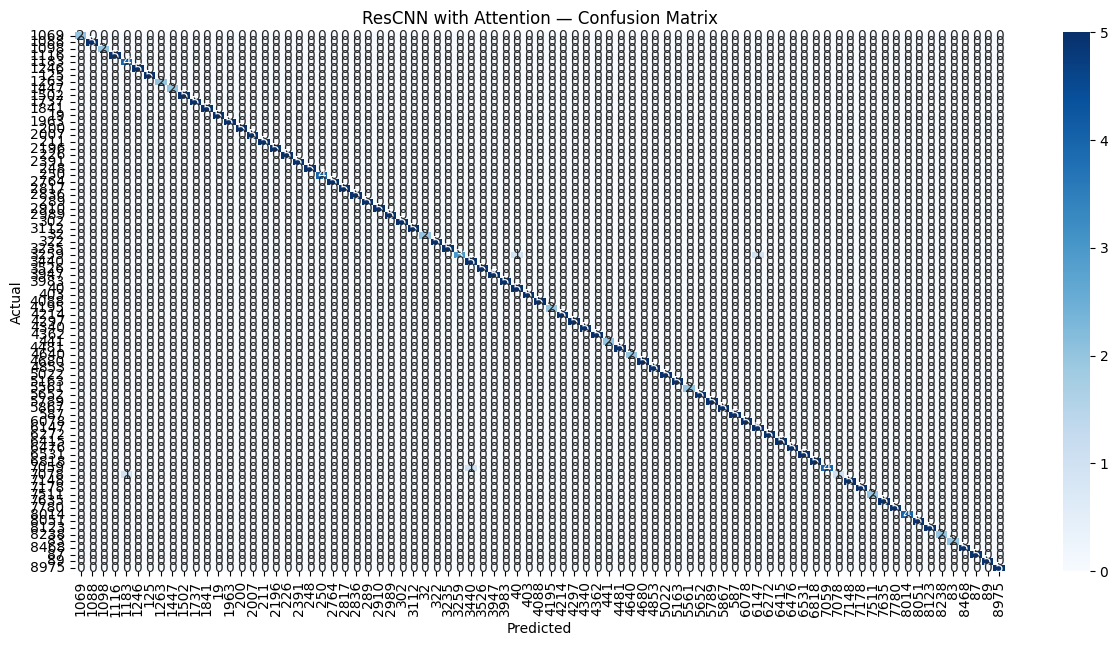

In [ ]:
models_acc_mel = {}
histories_all_mel = {}

# Define your models along with their names and input data
model_configs_mel = [
    {"name": "ResCNN with Attention", "builder": build_rescnn_with_attention, "X_train": X_train2_cnn, "y_train": y_train2_enc,
     "X_val": X_val2_cnn, "y_val": y_val2_enc, "X_test": X_test2_cnn, "y_test": y_test2_enc}

]

for cfg in model_configs_mel:
    print(f"\n=== Training {cfg['name']} (3 runs) ===")
    acc_list, f1_list = [], []
    hist_list = []
    best_run_idx = None
    best_acc = -1

    for run in range(3):
        print(f"\nTraining {cfg['name']} Run {run+1}/3...")

        # Build and Train model
        model = cfg['builder'](cfg['X_train'].shape[1:], num_classes=len(class_names))
        hist, ckpt = train_model_mel(
            model,
            cfg['name'],
            cfg['X_train'], cfg['y_train'],
            cfg['X_val'], cfg['y_val'],
            run
        )

        # Evaluate model
        metrics = evaluate_model(
            model,
            cfg["X_test"], cfg["y_test"],
            num_classes=len(class_names),
            class_names=class_names
        )

        acc, f1 = metrics["accuracy"], metrics["f1"]
        print(f"Run {run+1} Accuracy: {acc:.4f}, F1: {f1:.4f}")

        acc_list.append(acc)
        f1_list.append(f1)
        hist_list.append(hist)

        # Keep best run
        if acc > best_acc:
            best_acc = acc
            best_run_idx = run
            best_metrics = metrics

    # Aggregate metrics
    models_acc_mel[cfg['name']] = {
        "mean_accuracy": np.mean(acc_list),
        "std_accuracy": np.std(acc_list),
        "mean_f1": np.mean(f1_list),
        "std_f1": np.std(f1_list),
        "best_metrics": best_metrics
    }
    histories_all_mel[cfg['name']] = hist_list

    #  Summary
    print(f"\n{cfg['name']} Summary:")
    print(f"Mean Accuracy: {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Mean F1-score: {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print("Best Run Classification Report:\n", best_metrics["classification_report"])

    # Plot confusion matrix only
    plot_confusion_matrix(best_metrics, class_names, cfg['name'])


In [ ]:
MODEL_PATH = os.path.join(MODEL2_DIR)
def load_specific_model():
    print("\n" + "="*40)
    print("       MODEL SELECTION MENU      ")
    print("="*40)

    model_files = [f for f in os.listdir(MODEL2_DIR) if f.endswith('.h5') or f.endswith('.keras')]
    model_files.sort()

    if not model_files:
        print(f" No models found in {MODEL2_DIR}")
        return None

    # 2. List them for the user
    print(f"Found {len(model_files)} trained models:")
    for i, f in enumerate(model_files):
        print(f"  [{i+1}] {f}")

    # 3. Ask user to pick
    while True:
        choice = input(f"\nSelect Model (1-{len(model_files)}): ").strip()
        if choice.isdigit():
            idx = int(choice) - 1
            if 0 <= idx < len(model_files):
                selected_model_name = model_files[idx]
                print(f" Selected: {selected_model_name}")
                break
        print(" Invalid choice. Try again.")

    # 4. Load the chosen model
    model_path = os.path.join(MODEL2_DIR, selected_model_name)
    print(" Loading into memory... (This may take a few seconds)")
    try:
        model = tf.keras.models.load_model(model_path)
        print("🎉 Model Loaded Successfully!")
        return model
    except Exception as e:
        print(f" Error loading model: {e}")
        return None

# --- EXECUTE ---
# This updates the global 'model' variable with your choice
model = load_specific_model()

In [ ]:

def preprocess_for_inference(file_path):
    """
    Reads an audio file and converts it to the format the model expects.
    """
    try:

        y, _ = librosa.load(file_path, sr=SR)
        y, _ = librosa.effects.trim(y)
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel)
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + EPS)
        if mel_db.shape[1] < MAX_PAD_LEN:
            padding = MAX_PAD_LEN - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, padding)), mode="constant")
        else:
            mel_db = mel_db[:, :MAX_PAD_LEN]
        return mel_db[np.newaxis, ..., np.newaxis]

    except Exception as e:
        print(f"Error processing file: {e}")
        return None

In [ ]:
def validate_speaker_identity():
    print("\n" + "="*40)
    print("  VOICE IDENTITY VALIDATION SYSTEM  ")
    print("="*40)
    try:
        available_speakers = [d for d in os.listdir(SUBSET_DIR) if os.path.isdir(os.path.join(SUBSET_DIR, d))]
        available_speakers.sort()

        print(f"\n[INFO] Found {len(available_speakers)} Registered Speakers in Database:")

        print(", ".join(available_speakers))
        print("-" * 40)
    except Exception as e:
        print(f"[WARN] Could not list speakers from {SUBSET_DIR}: {e}")

    user_input = input("Enter Speaker ID to Validate (e.g., 1034): ").strip()

    speaker_folder = os.path.join(SUBSET_DIR, user_input)

    if not os.path.exists(speaker_folder):
        print(f"ERROR: Speaker ID '{user_input}' not found in the database.")
        print(f"   (Available path: {SUBSET_DIR})")
        return
    audio_files = [f for f in os.listdir(speaker_folder) if f.endswith('.flac') or f.endswith('.wav')]

    if not audio_files:
        print(f" ERROR: No audio files found for speaker {user_input}.")
        return

    random_file = random.choice(audio_files)
    file_path = os.path.join(speaker_folder, random_file)

    print(f"\n Source: {speaker_folder}")
    print(f" Audio File Selected: {random_file}")


    # print("Processing biometric features...")
    input_features = preprocess_for_inference(file_path)
    if input_features is None: return

    all_probs = model.predict(input_features, verbose=0)[0]
    try:
        target_index = list(le.classes_).index(user_input)
        target_prob = all_probs[target_index] * 100
    except ValueError:
        print(f" Warning: Speaker {user_input} is in the folder but was not in the Training Set (LabelEncoder).")
        target_prob = 0.0

    # 2. Get the actual Highest Probability
    predicted_index = np.argmax(all_probs)
    predicted_id = le.inverse_transform([predicted_index])[0]
    predicted_prob = all_probs[predicted_index] * 100

    top_3_indices = all_probs.argsort()[-3:][::-1]
    print("\n" + "-"*40)
    print(f"VALIDATION RESULTS FOR ID: {user_input}")
    print("-"*40)

    # Status
    if predicted_id == user_input:
        print(f"STATUS: AUTHENTICATED (Match Confirmed)")
    else:
        print(f"STATUS: ACCESS DENIED (Mismatch Detected)")

    print(f"\n1. Probability for Claimed ID ({user_input}):")
    print(f"    {'█' * int(target_prob/5)} {target_prob:.2f}%")

    print(f"\n2. System Prediction (Highest Confidence):")
    print(f"    ID: {predicted_id} | Confidence: {predicted_prob:.2f}%")

    print(f"\n3.  Full Probability Distribution (Top 3 Candidates):")
    for idx in top_3_indices:
        candidate_id = le.inverse_transform([idx])[0]
        prob = all_probs[idx] * 100
        marker = "◄ SYSTEM PICK" if idx == predicted_index else ""
        print(f"    - Speaker {candidate_id}: {prob:.2f}% {marker}")

    print("="*40 + "\n")

In [ ]:
validate_speaker_identity()

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import os
import random
import numpy as np
import matplotlib.pyplot as plt


# ORIGINAL_DATASET = "/content/drive/MyDrive/RP/LibriSpeech/train-clean-100"


def run_biometric_scan(target_id):

    spk_dir = os.path.join(ORIGINAL_DATASET, target_id)

    if not os.path.exists(spk_dir):
        spk_dir = os.path.join(SUBSET_DIR, target_id)
        if not os.path.exists(spk_dir):
            return "❌ Error", f"Speaker {target_id} not found in Original or Subset directories.", None

    audio_files = []
    for root, dirs, files in os.walk(spk_dir):
        for file in files:
            if file.endswith('.flac') or file.endswith('.wav'):
                audio_files.append(os.path.join(root, file))

    if not audio_files:
        return "❌ Error", f"No audio files found for User {target_id}", None


    random_file = random.choice(audio_files)


    try:
        input_features = preprocess_for_inference(random_file)
    except NameError:
        return "⚠️ Error", "Preprocessing function not found.", None

    if input_features is None:
        return "⚠️ Error", "Audio processing failed.", None


    try:
        probs = model.predict(input_features, verbose=0)[0]
    except NameError:
        return "⚠️ Error", "Model not loaded.", None


    pred_index = np.argmax(probs)
    confidence = probs[pred_index] * 100
    predicted_id = le.inverse_transform([pred_index])[0]

    filename_only = os.path.basename(random_file)
    if confidence > 75.0 and predicted_id == target_id:
        status_header = "✅ ACCESS GRANTED"
        msg = (f"User Verified: {predicted_id}\n"
               f"File Analyzed: {filename_only}\n"
               f"Confidence: {confidence:.2f}%")
    else:
        status_header = "⛔ ACCESS DENIED"
        msg = (f"Mismatch Detected!\n"
               f"Claimed ID: {target_id}\n"
               f"Detected Voice: {predicted_id}\n"
               f"Confidence: {confidence:.2f}%")

    top_5_idx = probs.argsort()[-5:][::-1]
    top_5_labels = [le.inverse_transform([i])[0] for i in top_5_idx]
    top_5_probs = probs[top_5_idx] * 100

    fig = plt.figure(figsize=(10, 5))
    colors = ['green' if x == predicted_id else 'gray' for x in top_5_labels]
    plt.barh(top_5_labels, top_5_probs, color=colors)
    plt.xlabel("Probability (%)")
    plt.title(f"Biometric Analysis: Top 5 Matches")
    plt.xlim(0, 100)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    return status_header, msg, fig

try:
    speaker_list = [d for d in os.listdir(SUBSET_DIR) if os.path.isdir(os.path.join(SUBSET_DIR, d))]
    speaker_list.sort()
except:
    speaker_list = ["Error: Run Setup First"]

with gr.Blocks(title="VoiceAuth System") as app:
    gr.Markdown("# 🎙️ VoiceAuth Biometric Security")
    gr.Markdown("### Final Year Project | Deep Learning Speaker Verification")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 1. Select User Identity")
            user_dropdown = gr.Dropdown(choices=speaker_list, label="Claimed Identity (Speaker ID)")
            scan_btn = gr.Button("🔐 RUN BIOMETRIC SCAN", variant="primary")

        with gr.Column():
            gr.Markdown("### 2. Validation Result")
            status_box = gr.Textbox(label="System Status", text_align="center")
            details_box = gr.Textbox(label="Diagnostic Report", lines=4)

    plot_output = gr.Plot(label="Confidence Distribution")

    scan_btn.click(
        fn=run_biometric_scan,
        inputs=user_dropdown,
        outputs=[status_box, details_box, plot_output]
    )

print("Launching Updated System Interface...")
app.launch(share=True, debug=True)

Launching Updated System Interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://22f6ec08f795959a4b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
